In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('drive/MyDrive/Colab Notebooks/Redshift Audio Visualizer')

Mounted at /content/drive


In [2]:
!pip install ffmpeg-python
!pip install pydub

In [ ]:
import numpy as np

arr = np.arange(0,2*np.pi,0.05)
print(arr.shape)
sixth = arr.shape[0] // 6
arr = np.hstack([arr[:sixth],arr[-sixth:]])
arr, np.pi/3, 10/6*np.pi

(126,)


(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 5.25,
        5.3 , 5.35, 5.4 , 5.45, 5.5 , 5.55, 5.6 , 5.65, 5.7 , 5.75, 5.8 ,
        5.85, 5.9 , 5.95, 6.  , 6.05, 6.1 , 6.15, 6.2 , 6.25]),
 1.0471975511965976,
 5.235987755982989)

In [3]:
import RSV
import importlib

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
importlib.reload(RSV)

<module 'RSV' from '/content/drive/MyDrive/Colab Notebooks/Redshift Audio Visualizer/RSV.py'>

In [26]:
# src = "audio/City Girl - Chroma Velocity - 08 Guaranteed Suicide (feat. rui ying).mp3"
src = "audio/City Girl - Chroma Velocity - 08 Guaranteed Suicide (feat. rui ying).wav"
anim = RSV.redshift_animation(src)
anim.details()

Input Audio File      :   audio/City Girl - Chroma Velocity - 08 Guaranteed Suicide (feat. rui ying).wav
Output Mp4 File       :   audio/City Girl - Chroma Velocity - 08 Guaranteed Suicide (feat_redshift_animation.mp4
Output Framerate      :   24
Cores using           :   2
Batchsize             :   30

Colormap              :   rainbow
Colormap Range        :   [0.1,1.0]
Colormap Periods      :   1
Colormap Mirror       :   True

Frequency Mapping     :   linear
Flip Frequency Map    :   False
Minimum Frequency     :   0
Maximum Frequency     :   300000.0
Minimum Volume        :   1e-10

Volume Offset         :   True
Volume Offset Max     :   1.5
Volume Alpha          :   True
Volume Alpha Range    :   [0.5,1.0]
Volume Alpha Mapping  :   sigmoid2

Starting radius       :   2.00000000
Resolution            :   0.20000000
Rate of Redshift      :   0.10000000

Figure Size           :   (6,6)
Figure X limit        :   6.0000
Figure Y limit        :   6.0000
Print Overall Progress:   True

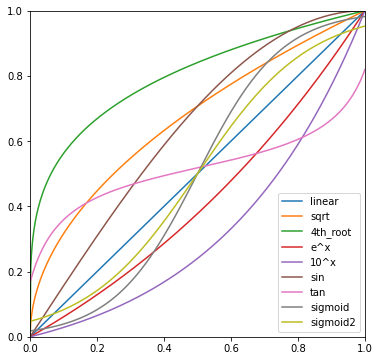

In [ ]:
anim.show_mapping_functions()

In [18]:
anim.colormap = 'rainbow'
anim.colormap_mirror = True
anim.colormap_periods=1
anim.colormap_range = (0.1,1.0)
anim.frequency_map = 'sigmoid'
anim.M = 0.1
anim.remove_temp_dirs = True
anim.print_local_progress = True
anim.temp_dirs = "temp_img_holder"
anim.remove_temp_dirs = False
anim.cores = 2
anim.batchSize = 30

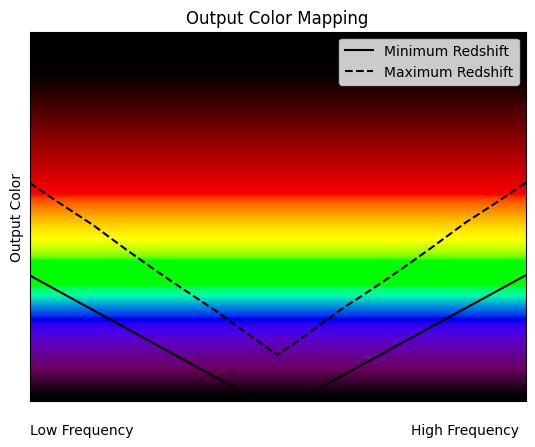

In [19]:
anim.show_colormap()

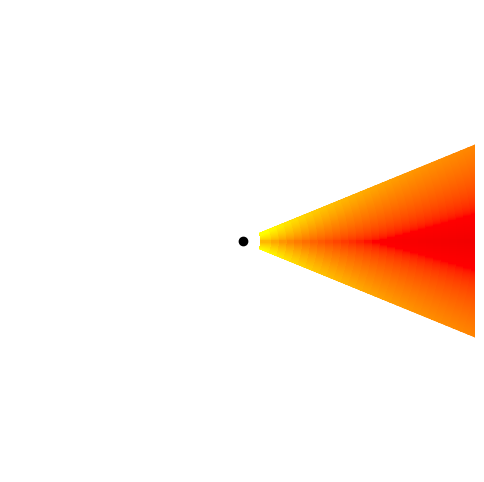

In [20]:
anim.show_full_frame(window='reduced')

In [23]:
# importlib.reload(RSV)
# anim = None
# anim = RSV.redshift_animation("Safety Dance.wav")
out = anim.check_frame_pollution()
# anim.optimize_threshold(use_max=False, thresh_percentage=0.5)

ValueError: File format b'ID3\x03' not understood. Only 'RIFF', 'RIFX', and 'RF64' supported.

0.00012495147029863905
Original Threshold
0.00012495147029863905


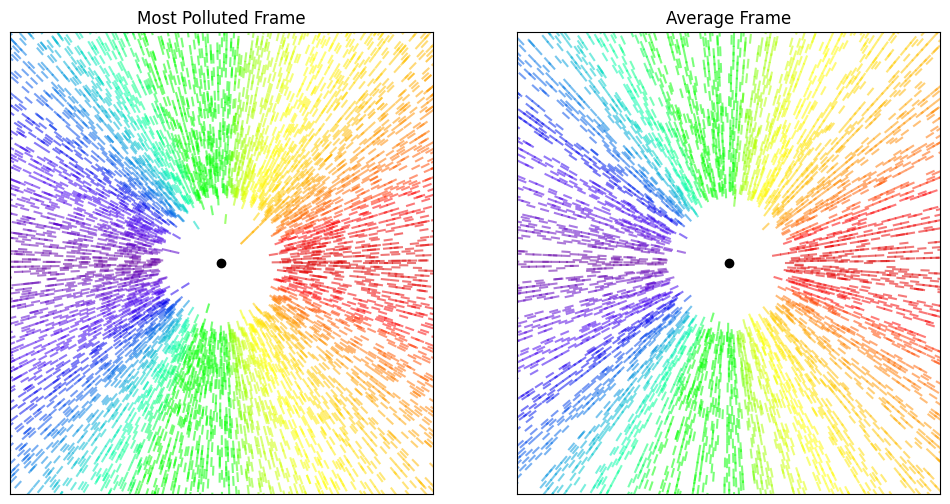

Modified Threshold
0.005066437254881925


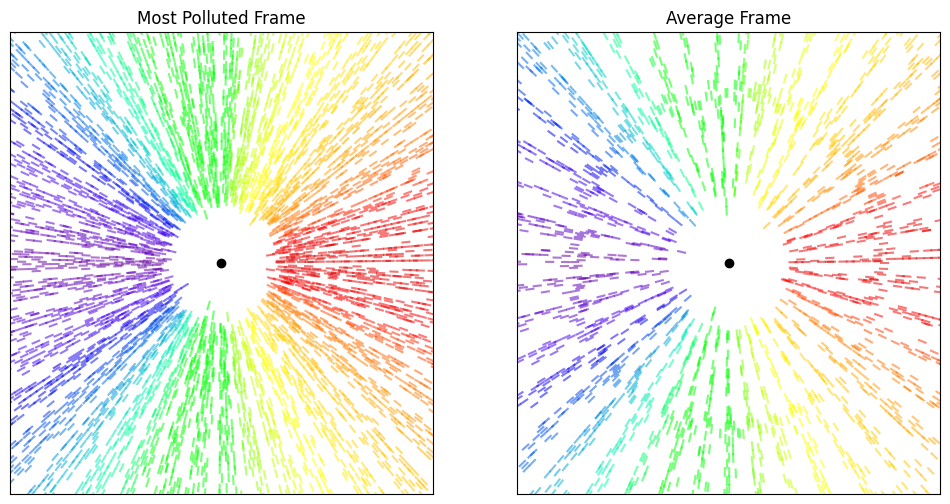

(array([0.00507159, 0.005081  , 0.00510441, ..., 4.09171953, 4.10414084,
        4.60076339]),
 array([0.00506707, 0.00506829, 0.00507762, ..., 2.20497433, 2.29740696,
        2.52906594]))

In [ ]:
anim.optimize_threshold(use_max=False, thresh_percentage=0.5)

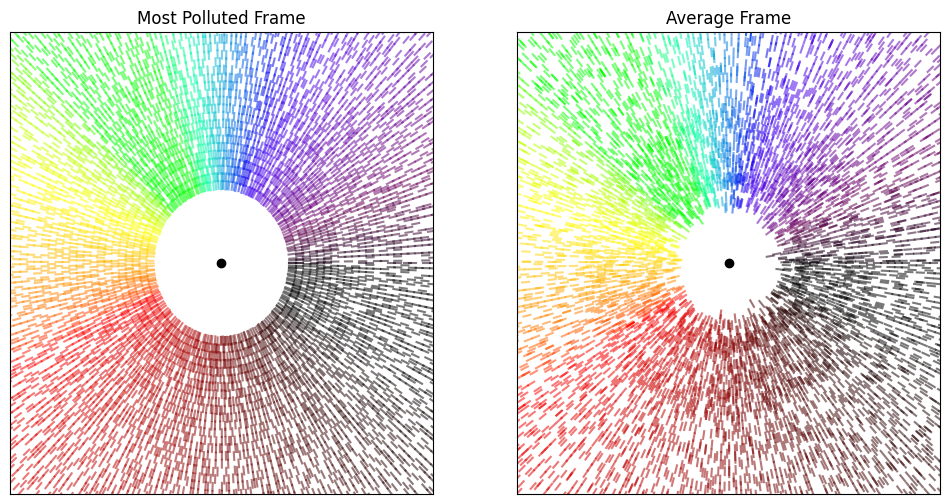

In [ ]:
out = anim.check_frame_pollution()

In [ ]:
# anim.min_Volume
dex = len(out[0]) // 2
out[0][dex]

np.float64(3.721038951468733e-05)

In [ ]:
max_f_heights = np.hstack(all_heights[max(frame_max-41,0):frame_max])
avg_f_heights = np.hstack(all_heights[max(frame_average-41,0):frame_average])

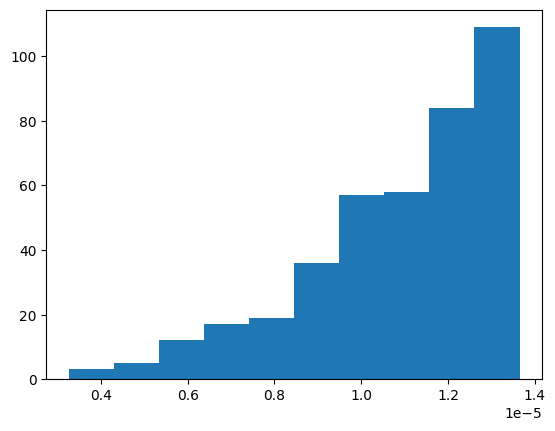

In [ ]:
max_f_heights = max_f_heights[max_f_heights.argsort()]

thresh = 400
plt.hist(max_f_heights[:thresh]);

In [ ]:
avg_f_heights.min()

np.float64(3.5797127319336106e-06)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
plots[0][1]

[array([[1.43092023, 1.57962575],
        [1.28692445, 1.4206655 ]]),
 (np.float64(0.0),
  np.float64(0.20588235294117635),
  np.float64(1.0),
  np.float64(1.0)),
 np.float64(0.523713806397683)]

Text(0.5, 1.0, 'Average Frame')

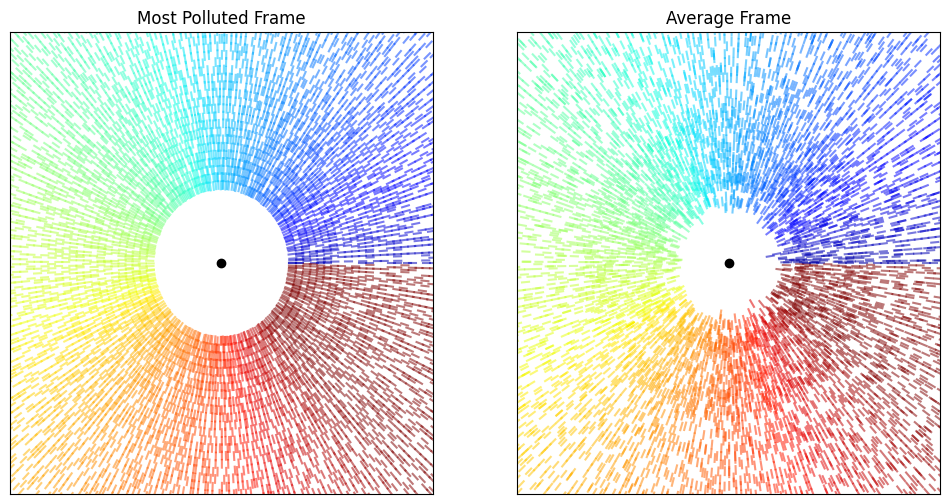

In [ ]:
frame_lc = []
for i in range(len(fc)):
  frame_lc.append(y[max(0,i-fw):i].sum())
frame_lc = np.array(frame_lc)

In [ ]:
,np.abs(frame_lc - frame_lc.mode()).argmin()

AttributeError: 'numpy.ndarray' object has no attribute 'mode'

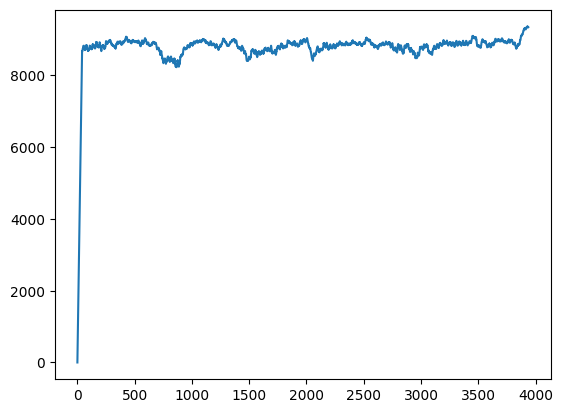

In [ ]:
plt.plot(x,frame_lc)

In [ ]:
anim.render(resume_from_frame=3930)

Required Number of Frames: 3937
All Frame Data Gathered
Creating Animation Frames
Current Batch: 3930 - 3937
	Organizing Frames
	Drawing Frames
Elapsed time: 0:00:35.045224
All Frames Drawn, Creating animation


KeyboardInterrupt: 

In [ ]:
import ffmpeg

In [ ]:
# ffmpeg.input('./' + anim.temp_dirs + '/frame_%0'+ str(len(str(len(Frames))))+'d.jpg', framerate = anim.samplerate,) \
#                 .output(anim.temp_output, vf= "pad=ceil(iw/2)*2:ceil(ih/2)*2") \
#                 .run(overwrite_output=True, capture_stdout=True, capture_stderr=True)


input_video = ffmpeg.input(anim.temp_output)

input_audio = ffmpeg.input(anim.filepath)

ffmpeg.concat(input_video, input_audio, v=1, a=1) \
    .output(anim.output) \
    .run(overwrite_output=True, capture_stdout=True, capture_stderr=True)

(b'',
 b"ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers\n  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)\n  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-li